# Configuration

In [2]:
import sys
import code
import os
import pickle

import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from tqdm import tqdm
import scipy.sparse
from scipy.sparse import csr_matrix
from gtfparse import read_gtf
from collections import defaultdict
from sklearn.metrics import auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

import networkx as nx
import dill
import re


# 1. 加载 autoreload 扩展
%load_ext autoreload

# 2. 设置模式为 "2" (表示自动重载所有模块)
%autoreload 2


sys.path.append('/home/wuyan/dygmamba_project/model/dygmamba/src/')

from benchmark.benchmark_model_new import analysis_tf_recovery, read_unibind_file

from benchmark.benchmark_model_new import analysis_tf_gene_data, dyg_tf_gene_result
    
from benchmark.benchmark_model_new import analysis_tf_gene_all_precision, analysis_tf_region

from benchmark.benchmark_model_new import plot_top_n_comparison

from benchmark.benchmark_model_new import analysis_region_gene, evaluate_r2g_benchmark, \
    plot_recovery_curves, analysis_region_gene_precision

from pdata.data_read import read_genenotation


from pdata.data_read import read_rna_from_txt, read_atac_featurecounts, anndata_to_bed
from pdata.data_preprocess import filter_atac_base

from pdata.data_preprocess import calculate_rp_distance, calculate_peak_peak_rp_distance
from pdata.data_preprocess import analyze_score_distribution
from pdata.data_preprocess import rna_preprocess, atac_preprocess
from pdata.data_preprocess import dataframe_to_anndata_sparse
from pdata.data_preprocess import find_zero_sum_elements


cell_type = "A549"
unibind_file = "/home/wuyan/dygmamba_project/data/cell_line/A549/unibind/A549_UniBind_search_j1is329r.tar.gz"


In [3]:
data_root= "/home/wuyan/dygmamba_project/"

output_path = data_root + "data/cell_line/" + cell_type + "/process/"

print("\n ********************---process rna data---***************************** \n")

adata_rna = ad.read_h5ad(output_path + "rna_origin.h5ad")

gtf_df = pd.read_pickle(output_path + "gene_info_data.pkl")

adata_rna_file = output_path + "rna_processed.h5ad"

gene_info_file = output_path + "gene_info_filtered.pkl"

adata_rna, gene_info = rna_preprocess(adata_rna, gtf_df, adata_rna_file, gene_info_file)

##### ******************************************************************************************

print("\n ********************---process atac data---***************************** \n")

adata_atac = ad.read_h5ad(output_path + "atac_origin.h5ad")

adata_atac = filter_atac_base(adata_atac)

adata_atac_file = output_path + "atac_processed.h5ad" 

adata_atac.write_h5ad(adata_atac_file)

##### ******************************************************************************************
print("\n ********************---process prior network---***************************** \n")    

adata_rp, adata_rp_dist = calculate_rp_distance(
    adata_atac=adata_atac, 
    adata_rna=adata_rna, 
    gene_info_df=gene_info, # 您的 DataFrame
    decay_dist=50000,       # 衰减参数：50kb (推荐)
    max_range=250000        # 硬性限制：250kb
)    

adata_peak_rp, adata_peak_rp_dist = calculate_peak_peak_rp_distance(adata_atac, 
                        decay_distance=50000, # 推荐 50kb
                        max_range=250000)

rp_stat = analyze_score_distribution(adata_rp)
rp_threshold = rp_stat["q0.75"]

rp_peak_stat = analyze_score_distribution(adata_peak_rp)
rp_peak_threshold = rp_peak_stat["q0.75"]

flag = 1
if flag==1:
    rp_threshold = 0
    rp_peak_threshold = 0

adata_rp_binary = adata_rp.copy()
adata_peak_rp_binary = adata_peak_rp.copy()

binary_mask = adata_rp_binary.X > rp_threshold
adata_rp_binary.X = binary_mask.astype(int)

peak_binary_mask = adata_peak_rp_binary.X > rp_peak_threshold
adata_peak_rp_binary.X = peak_binary_mask.astype(int)

##### ******************************************************************************************
zero_peaks, zero_genes = find_zero_sum_elements(adata_rp_binary)
if len(zero_peaks) > 0:
    print(f"Removing {len(zero_peaks)} zero-sum peaks from adata_rp")
    adata_rp = adata_rp[:, ~adata_rp.var_names.isin(zero_peaks)]
    adata_rp_dist = adata_rp_dist[:, ~adata_rp_dist.var_names.isin(zero_peaks)]
    adata_rp_binary = adata_rp_binary[:, ~adata_rp_binary.var_names.isin(zero_peaks)]
    adata_atac = adata_atac[:, ~adata_atac.var_names.isin(zero_peaks)]
    
if len(zero_genes) > 0:
    print(f"Removing {len(zero_genes)} zero-sum genes from adata_rp")
    adata_rp = adata_rp[ ~adata_rp.obs_names.isin(zero_genes), :]
    adata_rp_dist = adata_rp_dist[ ~adata_rp_dist.obs_names.isin(zero_genes), :]
    adata_rp_binary = adata_rp_binary[ ~adata_rp_binary.obs_names.isin(zero_genes), :]
    adata_rna = adata_rna[:, ~adata_rna.var_names.isin(zero_genes)]

adata_rp.write_h5ad(output_path + "peak_gene_rp_network.h5ad")
adata_peak_rp.write_h5ad(output_path + "peak_peak_rp_network.h5ad")
adata_rp_dist.write_h5ad(output_path + "peak_gene_rp_dist_network.h5ad")


 ********************---process rna data---***************************** 



AttributeError: module 'numpy' has no attribute 'void'

## Test

In [12]:

flag_tf_recovery = True
flag_tf_region = True
flag_tf_gene = True
flag_region_gene = True

data_path = "/home/wuyan/dygmamba_project/data/cell_line/" + cell_type + "/"

output_path = data_path + "benchmarkV7/"

os.makedirs(output_path, exist_ok=True )

adata_atac = ad.read_h5ad(data_path + "process/atac_processed.h5ad")

adata_rna = ad.read_h5ad(data_path + "process/rna_processed.h5ad")

unibind_df_file = output_path + "unibind_df.pkl"

model_result_path = data_path + "data_dyg/"

method_list = ["DyGMamba", "CellOracle", "FigR", "GLUE", "LINGER", "GRaNIE", "Pando"]

method_colors = {
    "Global": "#E64B35",      # 比如：红色
    "Active": "#4DBBD5",      # 比如：天蓝色
    "DyGMamba": "#9467BD",
    "GLUE": "#00A087",        # 比如：绿色
    "FigR": "#3C5488",        # 比如：深蓝色
    "CellOracle": "#F39B7F",  # 比如：橙色
    "LINGER": "#8491B4",      # 比如：灰蓝色
    "GRaNIE": "#91D1C2",      # 比如：青色
    "Pando": "#DC0000"        # 比如：深红色
}


unibind_threshold = 92
jaspar_threshold = 4.8
jaspar_score_threshold = 9
jaspar_q_threshold = 0.4
#############################################################################
#
# Unibind data processing
#
#############################################################################

unibind_df, count_region_df = read_unibind_file(unibind_file)

unibind_df["CellLine"] = unibind_df["CellLine"].str.split('_').str[0]
count_region_df["CellLine"] = count_region_df["CellLine"].str.split('_').str[0]

unibind_df = unibind_df[unibind_df['score']> unibind_threshold]
unibind_df = unibind_df[unibind_df['score']< 95]

count_region_df = count_region_df[count_region_df['TF'].isin(set(unibind_df['TF']))]

unibind_df.to_pickle(unibind_df_file)

count_region_df.to_pickle(output_path + "count_region_df.pkl")

####################################################################

jaspar_data = pd.read_pickle(data_path + "process/jaspar_df.pkl")
jaspar_data['sequence_name'] = jaspar_data['sequence_name'].str.replace(':','-')
jaspar_tf_peak = jaspar_data[['TF_Symbol', 'sequence_name', 'score', 'p-value', 'q-value']].copy()
jaspar_tf_peak.rename(columns= {'TF_Symbol': 'TF', 'sequence_name':'Peak'}, inplace = True)
jaspar_tf_peak.drop_duplicates(subset=['TF','Peak'], keep= 'first', inplace= True)

jaspar_tf_peak = jaspar_tf_peak[jaspar_tf_peak['q-value']< jaspar_q_threshold ]
jaspar_tf_peak = jaspar_tf_peak[jaspar_tf_peak['score']> jaspar_score_threshold]
jaspar_tf_peak['value'] = - np.log10(jaspar_tf_peak['p-value'])
mask = (jaspar_tf_peak['value']> jaspar_threshold ) & (jaspar_tf_peak['value']< 8)

new_jaspar_tf_peak = jaspar_tf_peak.loc[mask,['TF', 'Peak', 'value']].copy()

new_jaspar_tf_peak.to_pickle(data_path + 'process/pred_tf_peak.pkl')

In [13]:
# =========================
# 2. 工具函数：清理 sheet 名
# =========================
def safe_sheet_name(name, used_names=None, max_len=31):
    if used_names is None:
        used_names = set()

    name = re.sub(r'[:\\/*?\[\]]', '_', str(name))
    name = name[:max_len]

    base = name
    i = 1
    while name in used_names:
        suffix = f"_{i}"
        name = base[:max_len - len(suffix)] + suffix
        i += 1

    used_names.add(name)
    return name

# =========================
# 3. 工具函数：判断对象是否“有内容”
# =========================
def has_content(obj):
    if obj is None:
        return False

    if isinstance(obj, pd.DataFrame):
        return not obj.empty

    if isinstance(obj, pd.Series):
        return not obj.empty

    if isinstance(obj, dict):
        return len(obj) > 0

    if isinstance(obj, (list, tuple, set, np.ndarray)):
        return len(obj) > 0

    return True

# =========================
# 4. 工具函数：写入 Excel
# =========================
def write_object_to_excel(obj, writer, sheet_name, used_sheets):
    sheet_name = safe_sheet_name(sheet_name, used_sheets)

    # DataFrame
    if isinstance(obj, pd.DataFrame):
        obj.to_excel(writer, sheet_name=sheet_name, index=False)

    # Series
    elif isinstance(obj, pd.Series):
        obj.to_frame().to_excel(writer, sheet_name=sheet_name, index=True)

    # dict
    elif isinstance(obj, dict):
        for k, v in obj.items():
            sub_sheet = safe_sheet_name(f"{sheet_name}_{k}", used_sheets)

            if isinstance(v, pd.DataFrame):
                v.to_excel(writer, sheet_name=sub_sheet, index=False)
            elif isinstance(v, pd.Series):
                v.to_frame().to_excel(writer, sheet_name=sub_sheet, index=True)
            elif isinstance(v, (set, list, tuple, np.ndarray)):
                pd.DataFrame(list(v), columns=["value"]).to_excel(
                    writer, sheet_name=sub_sheet, index=False
                )
            else:
                pd.DataFrame({"value": [v]}).to_excel(
                    writer, sheet_name=sub_sheet, index=False
                )

    # list / tuple / set / ndarray
    elif isinstance(obj, (list, tuple, set, np.ndarray)):
        pd.DataFrame(list(obj), columns=["value"]).to_excel(
            writer, sheet_name=sheet_name, index=False
        )

    # 其他对象
    else:
        pd.DataFrame({"value": [obj]}).to_excel(
            writer, sheet_name=sheet_name, index=False
        )


# TF recovery

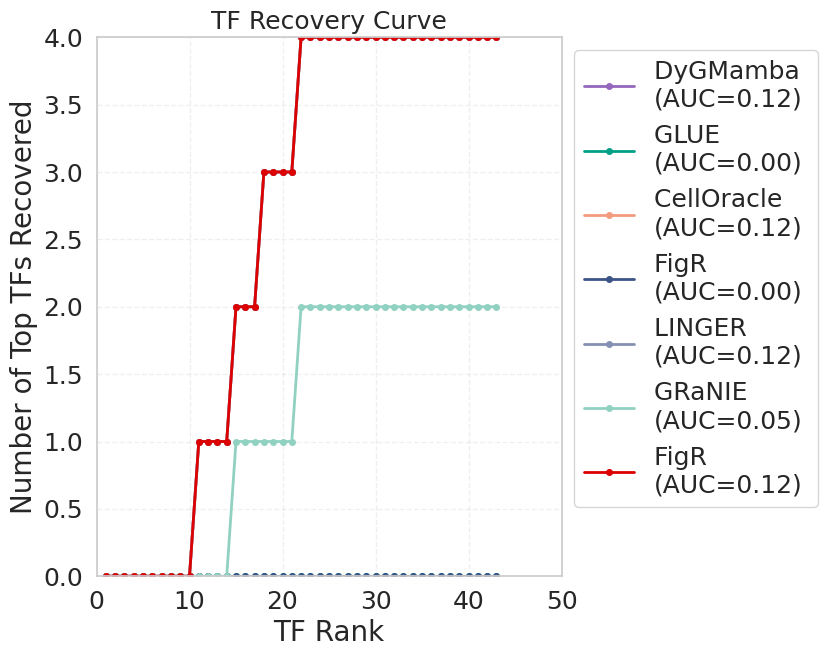

In [14]:
FONT_SIZE = 20

##############################################################################
#
# TF recovery
#
#############################################################################

if flag_tf_recovery == True:
    num_tf_result, tf_set_result = analysis_tf_recovery(data_path, output_path, method_list, 
                            method_colors=method_colors)
    
    
    
    #####################################
    benchmark_df = pd.read_pickle(output_path + "count_region_df.pkl")
    ground_truth_ranked = benchmark_df.sort_values(by="PeakCount", ascending=False)
    
    excel_file = os.path.join(output_path, "benchmark_all_results.xlsx")
    used_sheets = set()

    with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:

        # -------------------------------------------------
        # TF-recovery
        # -------------------------------------------------

        tf_recovery_df = pd.DataFrame({k: pd.Series(list(v)) for k, v in tf_set_result.items()})
        write_object_to_excel(tf_recovery_df, writer, "TF_recovery_set", used_sheets)

        write_object_to_excel(ground_truth_ranked, writer, "TF_recovery_rank", used_sheets)



# TF-region

重叠过滤：886276 → 886276 条边 (min_overlap_bp=1, min_overlap_frac=0.0)
✅ 构建完成：116401 条 TF-Peak 边，覆盖 36 个 TF，43911 个 Peak
Pando 格式已是连字符（chr1-100-200），无需转换。
      TF      TP       FP      FN  GroundTruth_Count  Predicted_Count  \
0   E2F6   151.0   3981.0   634.0              785.0           4132.0   
1  GABPA   553.0   9674.0  1506.0             2059.0          10227.0   
2   JUNB  2619.0   4163.0  9095.0            11714.0           6782.0   
3   REST    24.0  13336.0   199.0              223.0          13360.0   

   Precision    Recall    fscore    Method  
0   0.036544  0.192357  0.182828  DyGMamba  
1   0.054073  0.268577  0.255988  DyGMamba  
2   0.386169  0.223579  0.222304  DyGMamba  
3   0.001796  0.107623  0.067553  DyGMamba  
跳过方法 Pando: 找不到列 'Precision'
     Method  Precision  Rank
2  DyGMamba   0.386169     1
1  DyGMamba   0.054073     2
0  DyGMamba   0.036544     3
3  DyGMamba   0.001796     4
2      GLUE   0.328283     1
1      GLUE   0.098404     2
0      GLUE   0.055785     3

/home/wuyan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model_new.py:1160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Method', y=score_col,


跳过方法 Pando: 找不到列 'fscore'
     Method    fscore  Rank
1  DyGMamba  0.255988     1
2  DyGMamba  0.222304     2
0  DyGMamba  0.182828     3
3  DyGMamba  0.067553     4
1      GLUE  0.035810     1
0      GLUE  0.034186     2
2      GLUE  0.011094     3
3      GLUE  0.008631     4
1    LINGER  0.137165     1
0    LINGER  0.104393     2
2    LINGER  0.081105     3
3    LINGER  0.028697     4
0    GRaNIE  0.001274     1
1    GRaNIE  0.000000     2
0 0.30718561227576463


/home/wuyan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model_new.py:1160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Method', y=score_col,


跳过方法 Pando: 找不到列 'Recall'
     Method    Recall  Rank
1  DyGMamba  0.268577     1
2  DyGMamba  0.223579     2
0  DyGMamba  0.192357     3
3  DyGMamba  0.107623     4
1      GLUE  0.035940     1
0      GLUE  0.034395     2
2      GLUE  0.011098     3
3      GLUE  0.008969     4
1    LINGER  0.139874     1
0    LINGER  0.107006     2
2    LINGER  0.081270     3
3    LINGER  0.035874     4
0    GRaNIE  0.001274     1
1    GRaNIE  0.000000     2
0 0.3222923749392909


/home/wuyan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model_new.py:1160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Method', y=score_col,


跳过方法 Pando: 找不到列 'fscore'
     Method    fscore  Rank
1  DyGMamba  0.255988     1
2  DyGMamba  0.222304     2
0  DyGMamba  0.182828     3
3  DyGMamba  0.067553     4
1      GLUE  0.035810     1
0      GLUE  0.034186     2
2      GLUE  0.011094     3
3      GLUE  0.008631     4
1    LINGER  0.137165     1
0    LINGER  0.104393     2
2    LINGER  0.081105     3
3    LINGER  0.028697     4
0    GRaNIE  0.001274     1
1    GRaNIE  0.000000     2
0 0.30718561227576463


/home/wuyan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model_new.py:1160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Method', y=score_col,
/home/wuyan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model_new.py:1040: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=method_key, y=score_col, data=method_data, palette=palette)


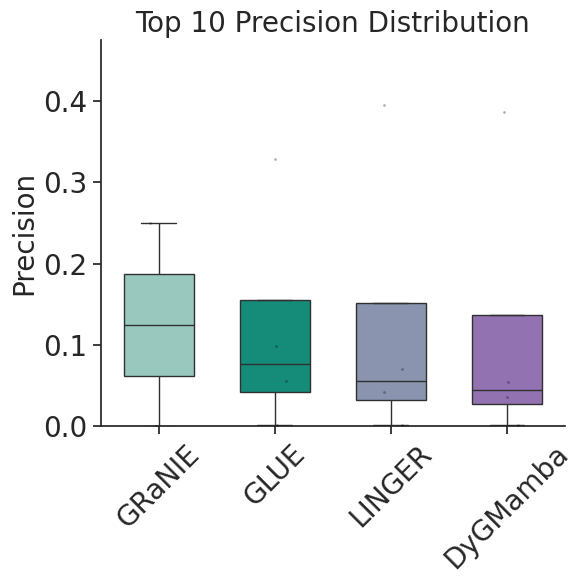

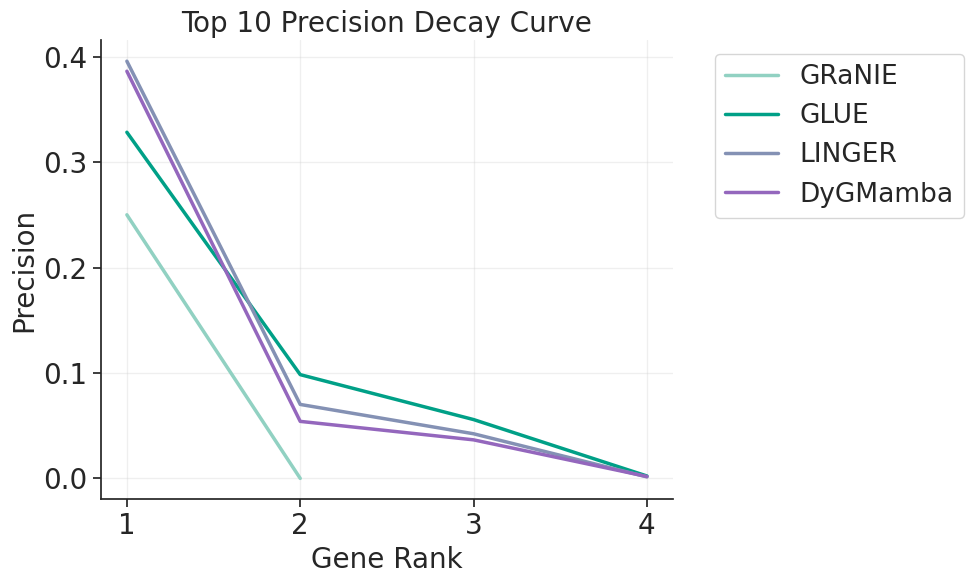

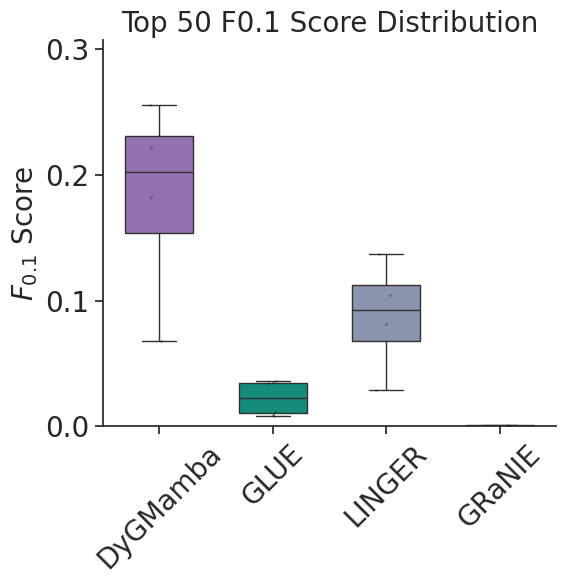

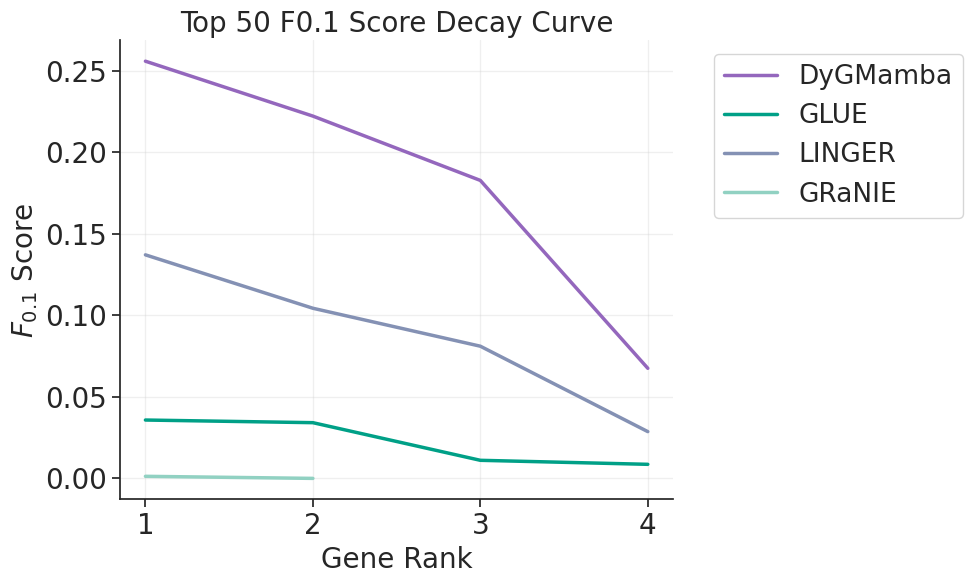

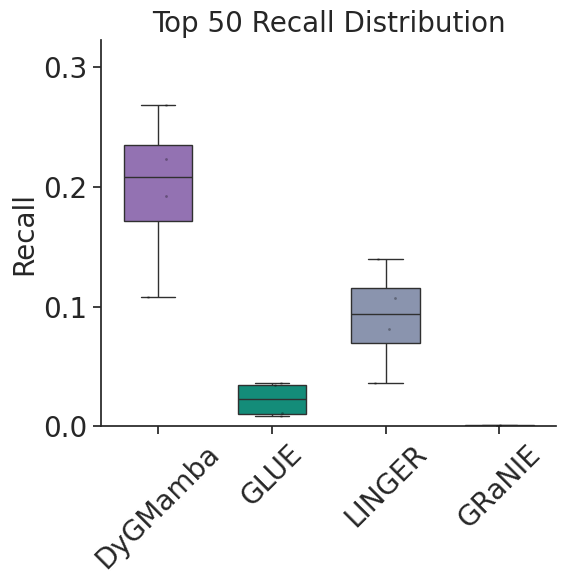

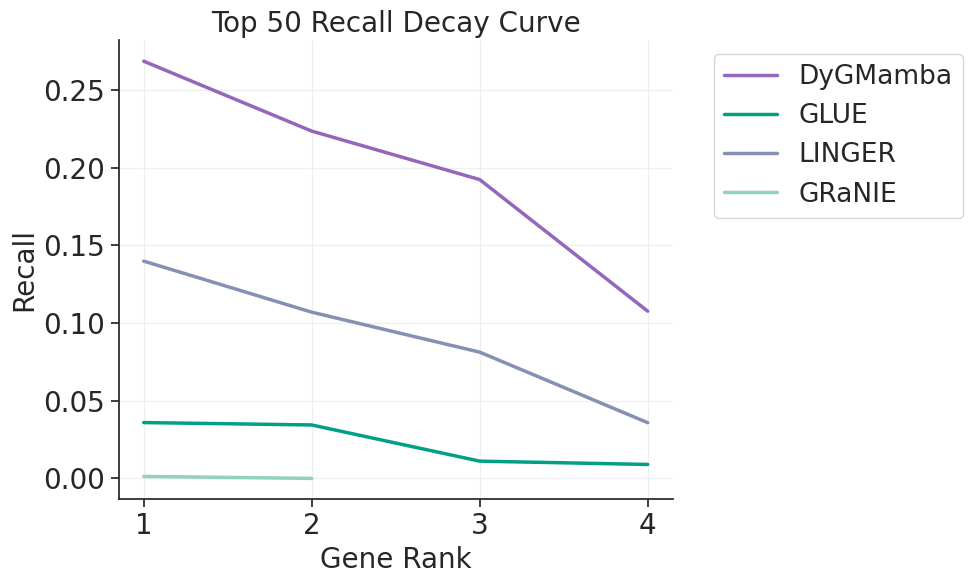

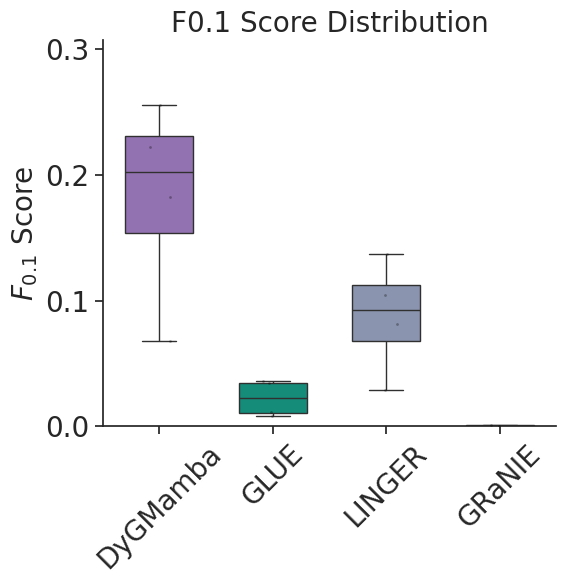

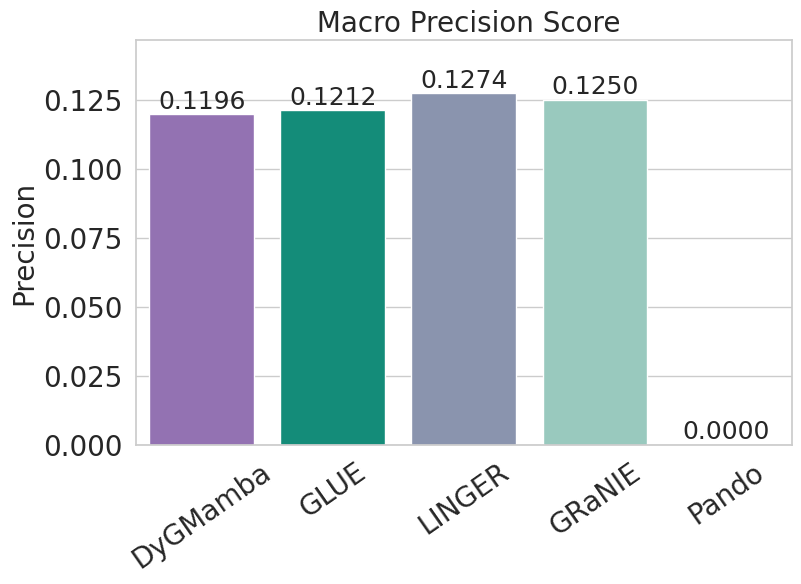

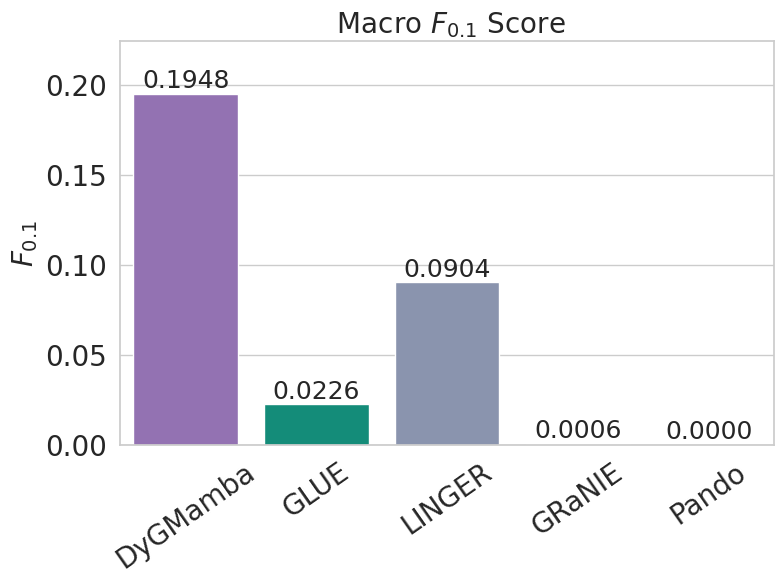

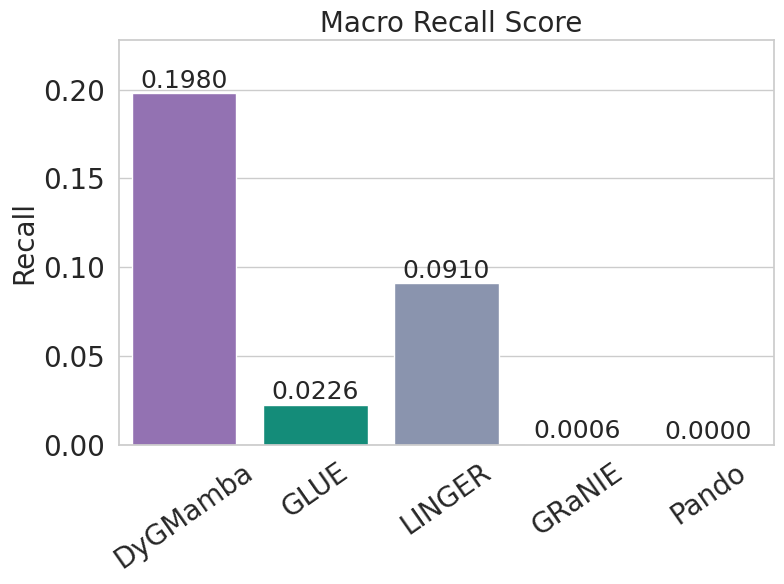

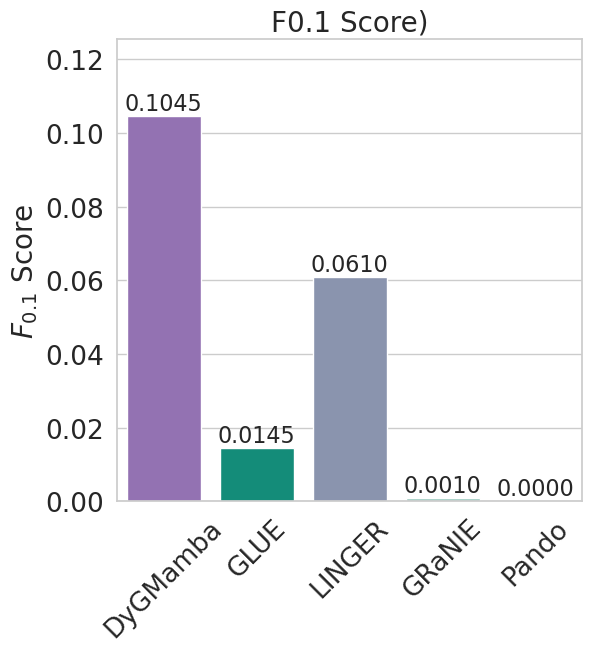

In [15]:
from benchmark.benchmark_model_new import calc_overall_metrics


beta = 0.1

##############################################################################
#
# TF-Region
#
##############################################################################
if flag_tf_region == True:
    ###################################
    # Benchmark

    tf_region_result, tf_region_grn = analysis_tf_region(unibind_df_file, data_path, beta, 
                                            method_list)
    
    all_tf_region_result = calc_overall_metrics(tf_region_result)
    
    
    ######################################################
    temp_list = []

    for k, df in tf_region_result.items():
        df_copy = df.copy() # 建议 copy 一下，避免修改原始字典里的数据
        temp_list.append(df_copy)

    # 一次性按行合并
    tf_region_per_df = pd.concat(temp_list, axis=0, ignore_index=True)

    with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:

        # -------------------------------------------------
        # TF-recovery
        # -------------------------------------------------

        write_object_to_excel(tf_region_per_df, writer, "TF_region_per", used_sheets)

        write_object_to_excel(all_tf_region_result, writer, "TF_region_all", used_sheets)


    print(tf_region_result['DyGMamba'])
    all_tf_region_result

    ###########################################################
    # plot

    FONT_SIZE = 20


    # 2. 调用函数
    # 例如：对比前 10 个基因的 Precision
    top_results = plot_top_n_comparison(method_dict=tf_region_result, 
        output_file=output_path + 'Benchmark of TF-Region',
        top_n=10, score_col="Precision", palette = method_colors, beta= beta)

    # 2. 调用函数
    # 例如：对比前 50 个基因的 fscore
    top_results = plot_top_n_comparison(method_dict= tf_region_result, 
        output_file= output_path + 'Benchmark of TF-Region',
        top_n= 50, score_col= "fscore", palette = method_colors, beta = beta,
        my_order = method_list)


    top_results = plot_top_n_comparison(method_dict=tf_region_result, 
        output_file=output_path + 'Benchmark of TF-Region',
        top_n = 50, score_col="Recall", palette = method_colors, beta= beta, 
        my_order = method_list)
    ###########################
    # Boxplot
    ###########################

    top_results = plot_top_n_comparison(method_dict=tf_region_result, 
        output_file=output_path + 'Benchmark of TF-Region Comparison of F score',
        score_col="fscore", palette = method_colors, beta= beta, 
        my_order = method_list, decay_curve = False)

    from benchmark.benchmark_model_new import plot_top_n_mean_comparsion

    plot_top_n_mean_comparsion(tf_region_result, output_file = output_path + "Benchmark of TF-Region Overall ", top_n=None, 
                            score_col="Precision", palette=method_colors, my_order = method_list,
                            beta = beta)

    plot_top_n_mean_comparsion(tf_region_result, output_file = output_path + "Benchmark of TF-Region Overall ", top_n=None, 
                            score_col="fscore", palette=method_colors, my_order = method_list,
                            beta = beta)

    plot_top_n_mean_comparsion(tf_region_result, output_file = output_path + "Benchmark of TF-Region Overall ", top_n=None, 
                            score_col="Recall", palette=method_colors, my_order = method_list,
                            beta = beta)

    from benchmark.benchmark_model_new import plot_comparsion

                        
    plot_comparsion(all_tf_region_result, output_path + 'Benchmark of TF-Region', 
                    score_col = "F_score", palette=method_colors, my_order = method_list, beta = beta)







# region-gene

/home/wuyan/conda_env/dygmamba39/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/wuyan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model_new.py:2136: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(group['value_bench'], group['value_method'])
/home/wuyan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model_new.py:2136: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(group['value_bench'], group['value_method'])
/home/wuyan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model_new.py:1862: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(merged_df['pred_score'], merged_df['hic_score'])
/home/wuyan/dygmamba_project/model/dygmamba/src/

✓ 已保存：Region-Gene PR Curve
        Method  Precision  Rank
1758  DyGMamba   1.000000     1
13    DyGMamba   0.666667     2
978   DyGMamba   0.500000     3
1844  DyGMamba   0.500000     4
1129  DyGMamba   0.500000     5
...        ...        ...   ...
1264    GRaNIE   0.000000    46
1263    GRaNIE   0.000000    47
1262    GRaNIE   0.000000    48
1261    GRaNIE   0.000000    49
1260    GRaNIE   0.000000    50

[300 rows x 3 columns]
0 1


/home/wuyan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model_new.py:1160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Method', y=score_col,


        Method  Recall  Rank
1997  DyGMamba     1.0     1
1996  DyGMamba     1.0     2
1     DyGMamba     1.0     3
2     DyGMamba     1.0     4
1995  DyGMamba     1.0     5
...        ...     ...   ...
1264    GRaNIE     0.0    46
1263    GRaNIE     0.0    47
1262    GRaNIE     0.0    48
1261    GRaNIE     0.0    49
1260    GRaNIE     0.0    50

[300 rows x 3 columns]
0 1


/home/wuyan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model_new.py:1160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Method', y=score_col,


        Method   F_score  Rank
1758  DyGMamba  0.990196     1
13    DyGMamba  0.985366     2
1493  DyGMamba  0.980583     3
893   DyGMamba  0.980583     4
978   DyGMamba  0.980583     5
...        ...       ...   ...
1264    GRaNIE  0.000000    46
1263    GRaNIE  0.000000    47
1262    GRaNIE  0.000000    48
1261    GRaNIE  0.000000    49
1260    GRaNIE  0.000000    50

[300 rows x 3 columns]
0 1


/home/wuyan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model_new.py:1160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Method', y=score_col,


        Method  AUPRC  Rank
152   DyGMamba   1.00     1
612   DyGMamba   1.00     2
326   DyGMamba   1.00     3
104   DyGMamba   1.00     4
893   DyGMamba   1.00     5
...        ...    ...   ...
1050    GRaNIE   0.75    46
1055    GRaNIE   0.75    47
976     GRaNIE   0.75    48
1739    GRaNIE   0.75    49
1625    GRaNIE   0.75    50

[300 rows x 3 columns]
0.26666666666666666 1


/home/wuyan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model_new.py:1160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Method', y=score_col,


✓ 已保存：Region-Gene Precision vs $F_{0.1}$


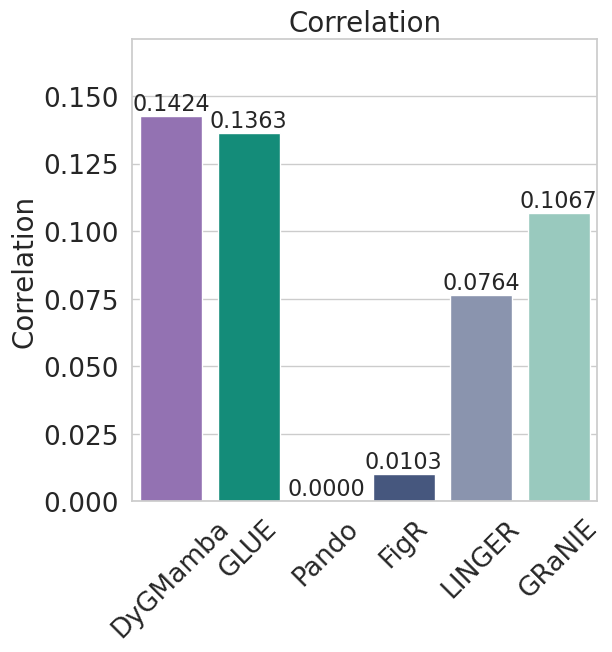

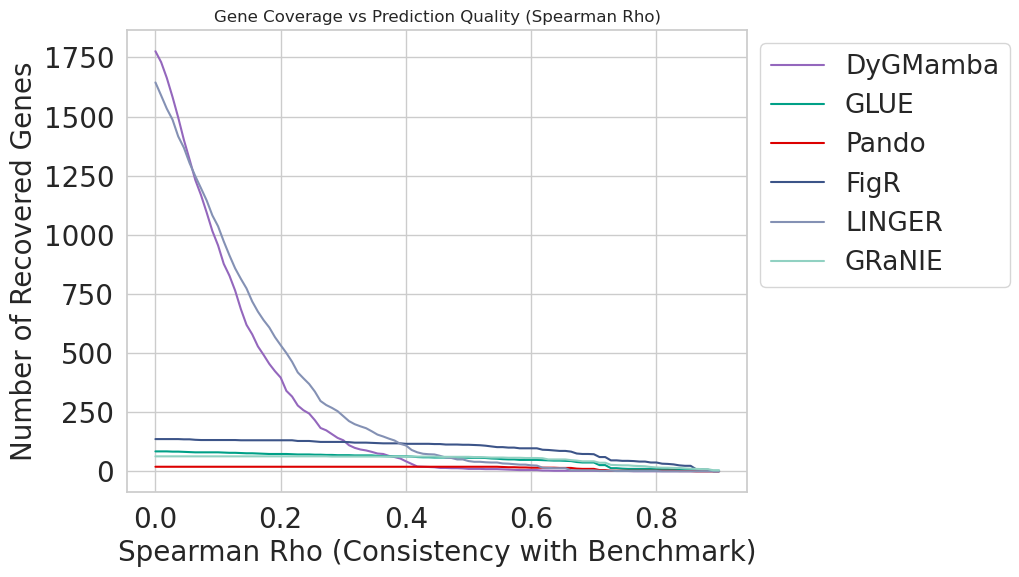

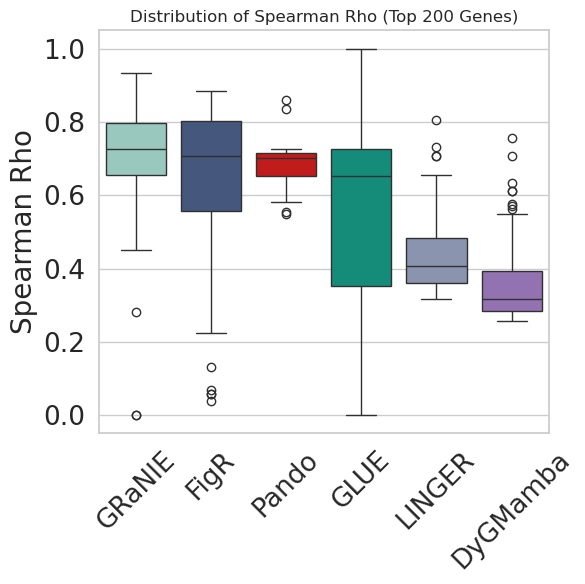

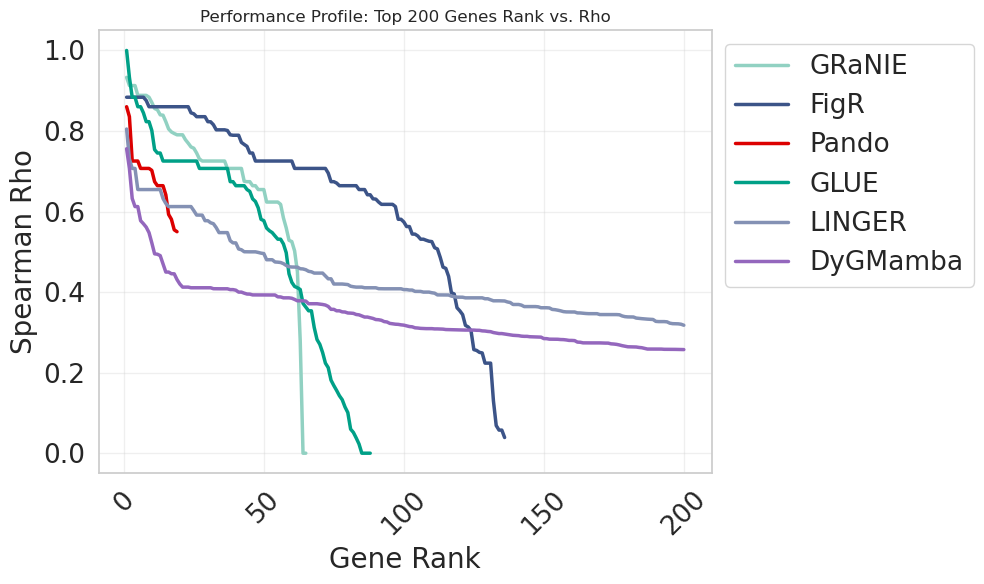

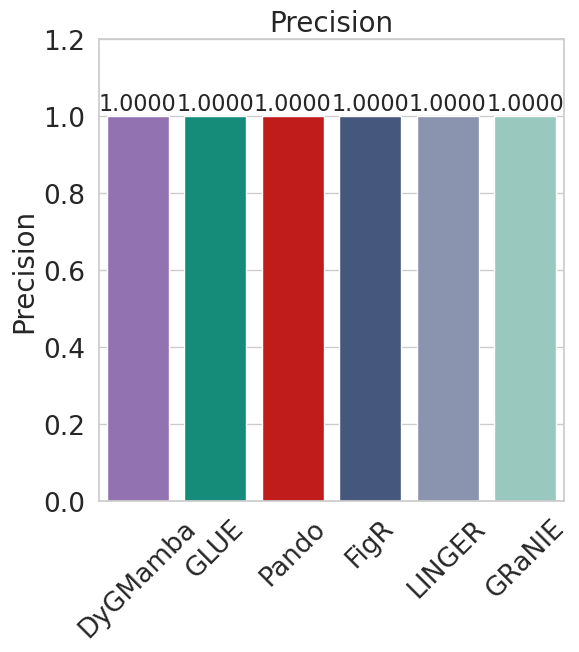

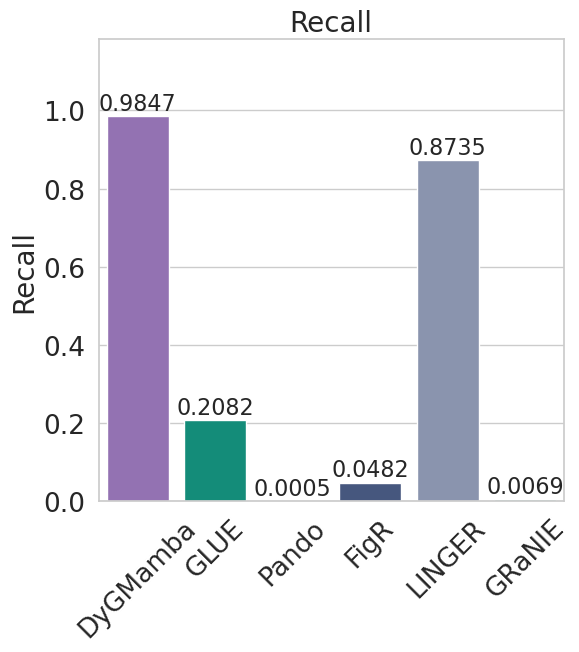

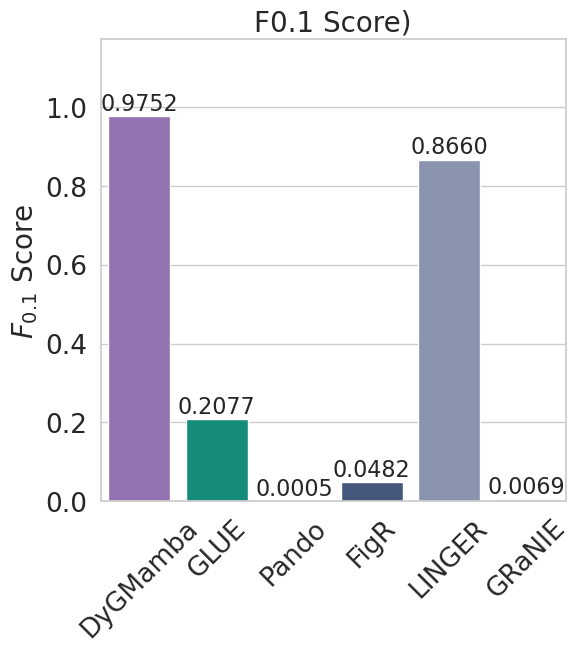

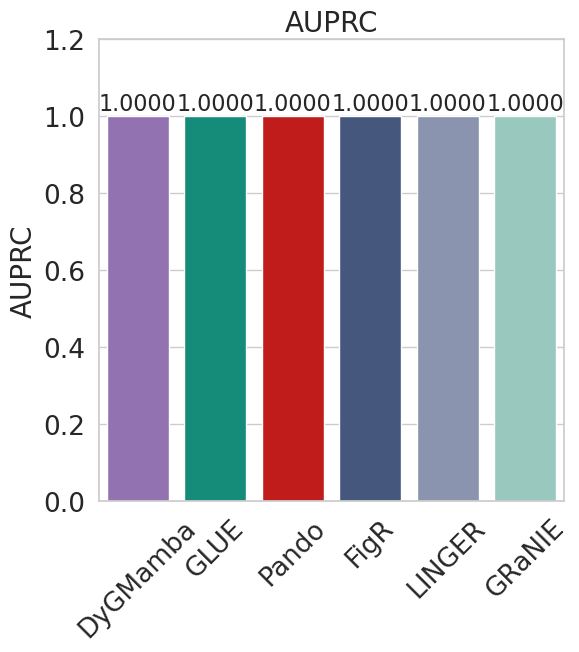

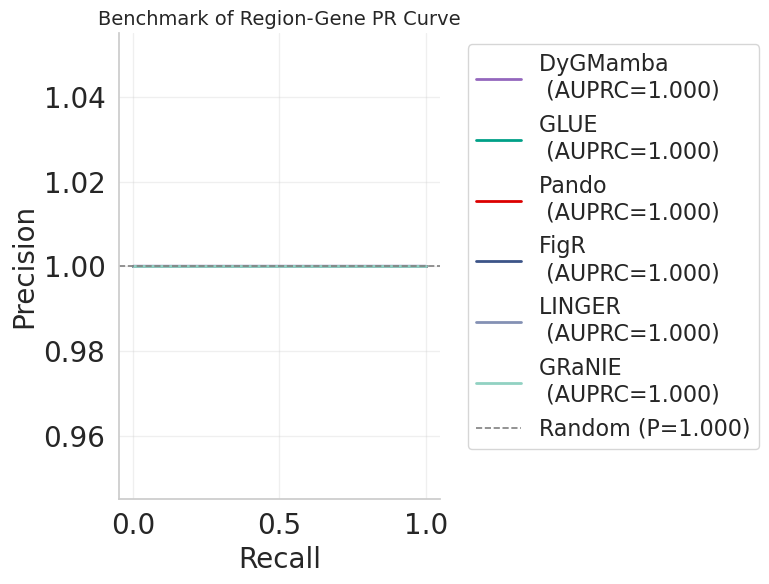

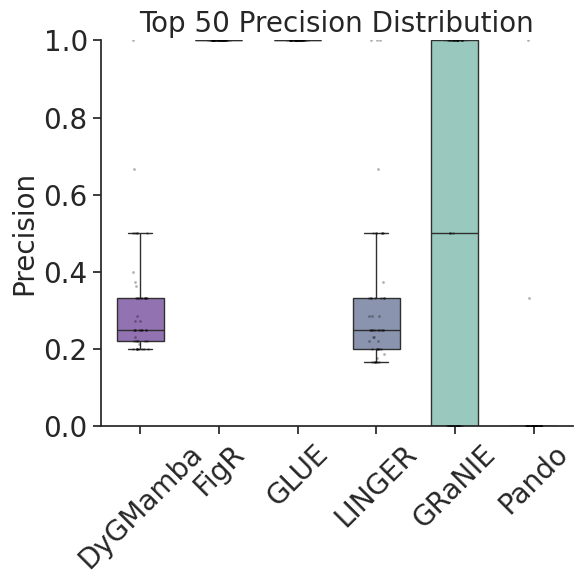

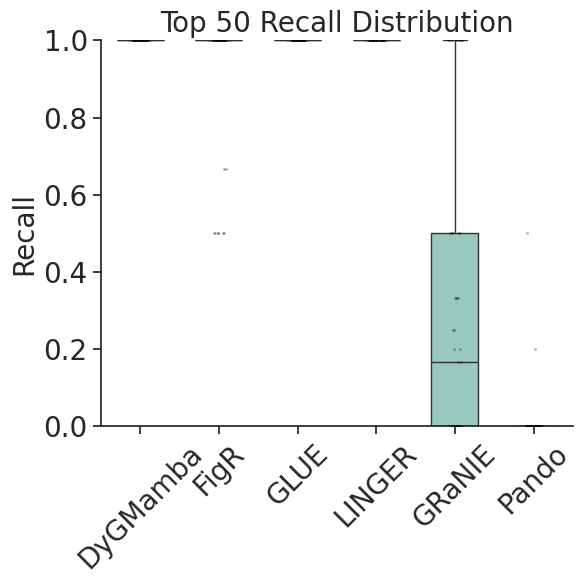

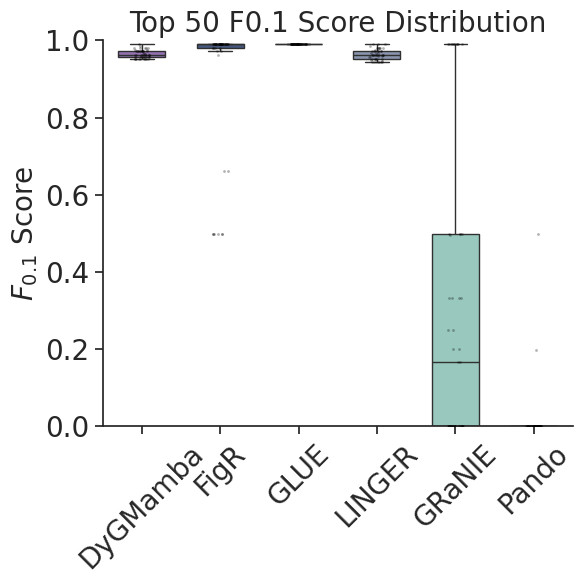

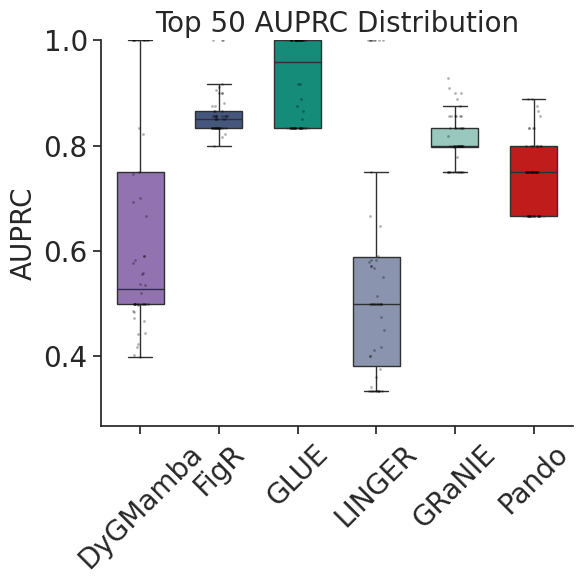

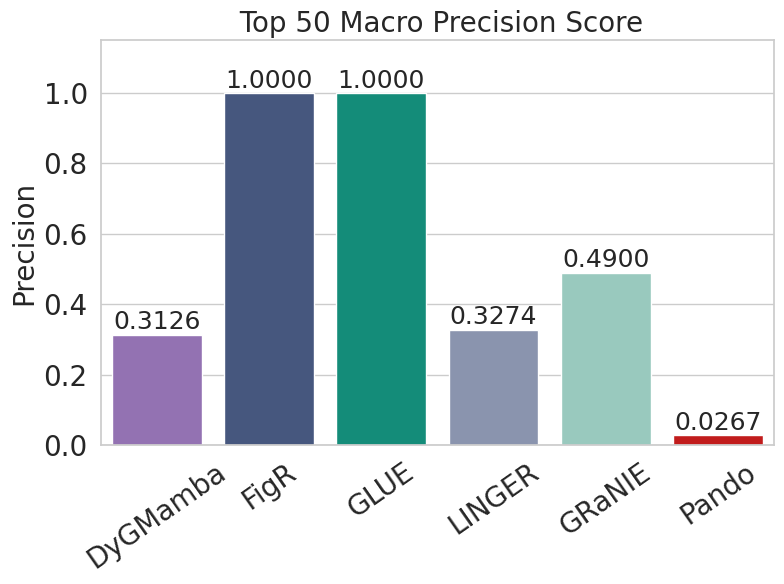

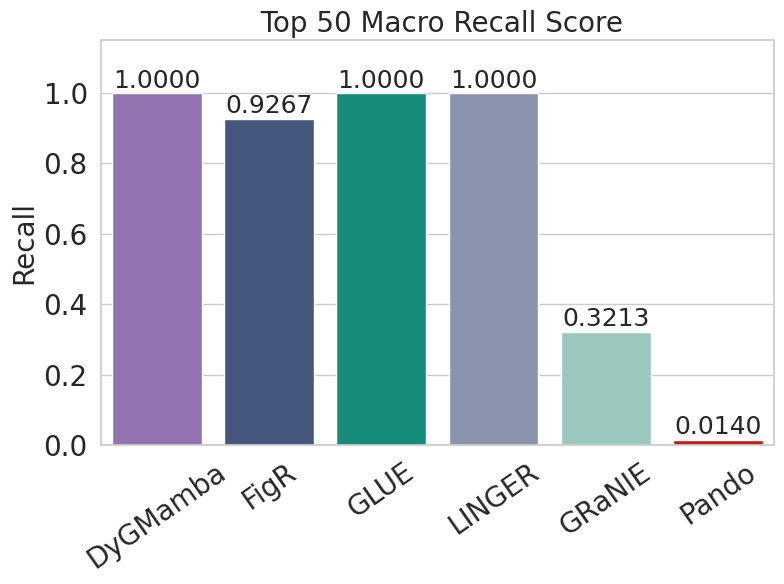

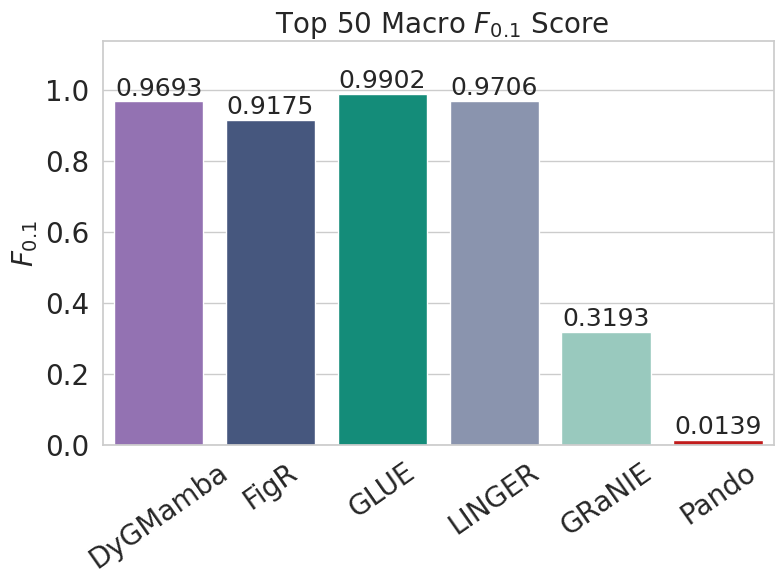

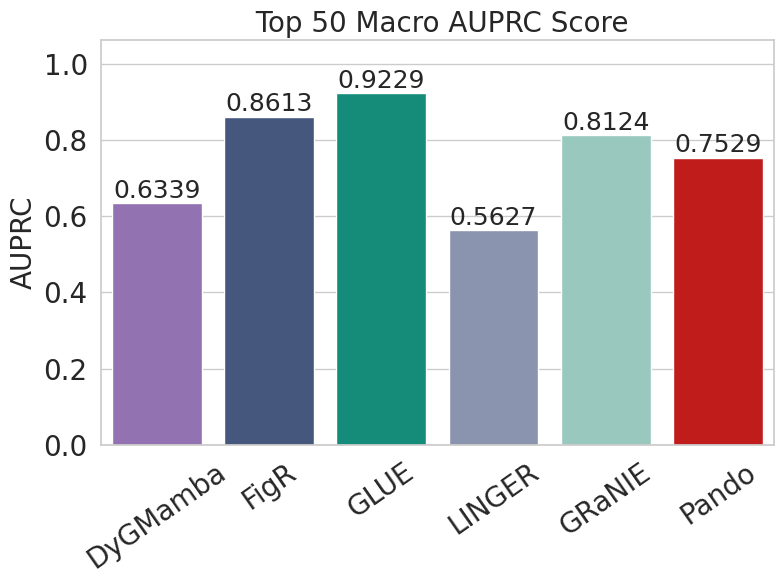

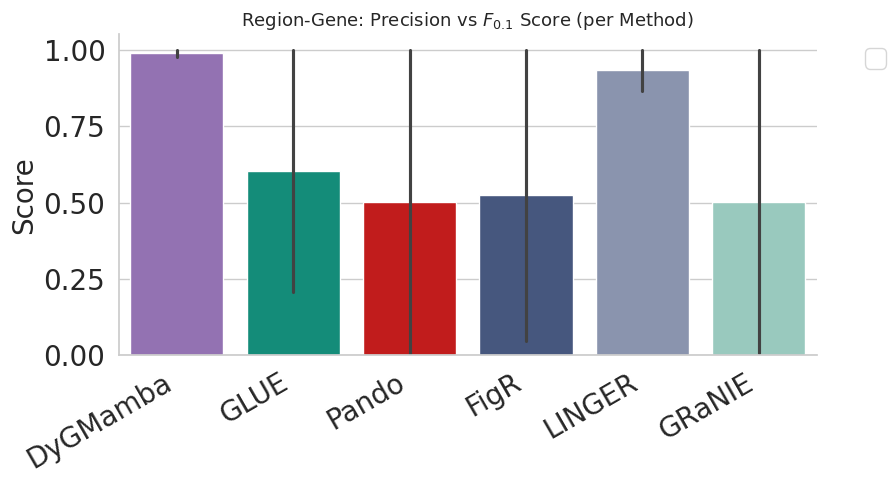

In [16]:

##############################################################################
#
# Region-Gene
#
##############################################################################
if flag_region_gene == True:
    
    region_gene_total_corr, region_gene_per_corr_df, region_gene_method_data, benchmark_peak_gene_df = \
        analysis_region_gene(data_path, output_path, method_list,
                             hic_threshold = 140, hic_threshold_lower = 30,
                             self_threshold = 0.7)

    region_gene_per_corr_df['Abs_Spearman_Rho'] = region_gene_per_corr_df['Spearman_Rho'].abs()
    #################################
    # Correlation

    plot_data = region_gene_total_corr.T.reset_index()
    plot_data.columns = ['Method', 'Correlation']

    
    region_gene_total_precision, region_gene_per_precision, pr_curve_data = \
        analysis_region_gene_precision(benchmark_peak_gene_df, region_gene_method_data, 
                               output_path, method_colors, beta=beta)


    ##################################################
    temp_list = []

    for k, df in region_gene_per_precision.items():
        df_copy = df.copy() # 建议 copy 一下，避免修改原始字典里的数据
        temp_list.append(df_copy)

    # 一次性按行合并
    region_gene_per_df = pd.concat(temp_list, axis=0, ignore_index=True)

    with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:

        write_object_to_excel(region_gene_total_corr, writer, "Region_gene_total_corr", used_sheets)
        
        write_object_to_excel(region_gene_per_corr_df, writer, "Region_gene_per_corr", used_sheets)

        write_object_to_excel(region_gene_total_precision, writer, "Region_gene_total_precision", used_sheets)

        write_object_to_excel(region_gene_per_df, writer, "Region_gene_per_precision", used_sheets)




    ##########################################################################

    from benchmark.benchmark_model_new import plot_comparsion
    from benchmark.benchmark_model_new import plot_top_n_df_comparison, plot_PR_curve, plot_serval_metric_comparsion

    plot_comparsion(plot_data, output_path + 'Benchmark of Region-Gene Correlation Comparison', 
                    score_col = "Correlation", palette=method_colors, my_order = method_list, beta = beta)

    #############################
    # score analysis

    plot_recovery_curves(region_gene_per_corr_df, output_path + 'Benchmark of Recovery Curve of Region-Gene Prediction.png',
                        method_colors,
                        compared_method='Abs_Spearman_Rho')


    plot_top_n_df_comparison(region_gene_per_corr_df, 
                            output_path + 'Benchmark of Region-Gene Comparison of Top 200 Spearman Rho',
                            method_colors, top_n=200, 
                            compare_method='Abs_Spearman_Rho', beta=beta)

    #############################
    # score analysis

    plot_comparsion(region_gene_total_precision, output_path + "Benchmark of Region-Gene Comparison", 
                    score_col="Precision", palette=method_colors, my_order = method_list)

    plot_comparsion(region_gene_total_precision, output_path + "Benchmark of Region-Gene Comparison", 
                    score_col="Recall", palette=method_colors, my_order = method_list)

    plot_comparsion(region_gene_total_precision, output_path + "Benchmark of Region-Gene Comparison", 
                    score_col="F_score", palette=method_colors, my_order = method_list, beta= beta)

    plot_comparsion(region_gene_total_precision, output_path + "Benchmark of Region-Gene Comparison", 
                    score_col="AUPRC", palette=method_colors, my_order = method_list)

    plot_PR_curve(pr_curve_data,  benchmark_peak_gene_df, region_gene_total_precision,
                    output_path, method_colors)

    ###################################
    # per region-gene
    plot_top_n_comparison(region_gene_per_precision, 
        output_file=output_path + 'Benchmark of Region-Gene Comparison',
        top_n=50, score_col="Precision", palette = method_colors, 
        beta= beta, my_order = method_list, decay_curve = False)

    plot_top_n_comparison(region_gene_per_precision, 
        output_file=output_path + 'Benchmark of Region-Gene Comparison',
        top_n=50, score_col="Recall", palette = method_colors, 
        beta= beta, my_order = method_list, decay_curve = False)

    plot_top_n_comparison(region_gene_per_precision, 
        output_file=output_path + 'Benchmark of Region-Gene Comparison',
        top_n=50, score_col="F_score", palette = method_colors, 
        beta= beta, my_order = method_list, decay_curve = False)

    plot_top_n_comparison(region_gene_per_precision, 
        output_file=output_path + 'Benchmark of Region-Gene Comparison',
        top_n=50, score_col="AUPRC", palette = method_colors, 
        beta= beta, my_order = method_list, decay_curve = False)

    plot_top_n_mean_comparsion(region_gene_per_precision, 
                            output_file = output_path + "Benchmark of Region-Gene Overall ", 
                            top_n=50, score_col="Precision", palette=method_colors, 
                            my_order = method_list, beta = beta)

    plot_top_n_mean_comparsion(region_gene_per_precision, 
                            output_file = output_path + "Benchmark of Region-Gene Overall ", 
                            top_n=50, score_col="Recall", palette=method_colors, 
                            my_order = method_list, beta = beta)

    plot_top_n_mean_comparsion(region_gene_per_precision, 
                            output_file = output_path + "Benchmark of Region-Gene Overall ", 
                            top_n=50, score_col="F_score", palette=method_colors, 
                            my_order = method_list, beta = beta)

    plot_top_n_mean_comparsion(region_gene_per_precision, 
                            output_file = output_path + "Benchmark of Region-Gene Overall ", 
                            top_n=50, score_col="AUPRC", palette=method_colors, 
                            my_order = method_list, beta = beta)


    plot_serval_metric_comparsion(region_gene_total_precision, output_path, method_colors, beta = beta)


# TF-Gene

>>> 开始评估预测能力 (Predictability)...


>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...


/home/wuyan/dygmamba_project/model/dygmamba/src/analysis/assess.py:157: RuntimeWarning: invalid value encountered in scalar divide
  model_precision = float(model_TP/(model_TP+model_FP))
/home/wuyan/dygmamba_project/model/dygmamba/src/analysis/assess.py:157: RuntimeWarning: invalid value encountered in scalar divide
  model_precision = float(model_TP/(model_TP+model_FP))


       Method  Precision    Recall       FPR       AUC    F-beta   TP    FN  \
0    DyGMamba   0.481788  0.107778  0.094591  0.506594  0.465784  291  2409   
1        FigR   0.000000  0.000000  0.000000  0.500000  0.000000    0  2700   
2  CellOracle   0.474702  0.118148  0.106679  0.505735  0.460930  319  2381   
3      LINGER   0.488421  0.085926  0.073436  0.506245  0.466773  232  2468   
4      GRaNIE   0.000000  0.000000  0.000000  0.500000  0.000000    0  2700   
5       Pando   0.000000  0.000000  0.000302  0.499849  0.000000    0  2700   

    FP  
0  313  
1    0  
2  353  
3  243  
4    0  
5    1  
跳过方法 GLUE: 找不到列 'Correlation'
        Method  Correlation  Rank
210   DyGMamba     1.000000     1
212   DyGMamba     1.000000     2
997   DyGMamba     1.000000     3
742   DyGMamba     1.000000     4
1170  DyGMamba     1.000000     5
...        ...          ...   ...
33       Pando    -0.023808    34
14       Pando    -0.026019    35
32       Pando    -0.036299    36
2        Pand

/home/wuyan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model_new.py:1160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Method', y=score_col,


  [警告] DyGMamba 缺少 TP/FP/FN 列，Micro 平均以 Macro 代替。
  [警告] FigR 缺少 TP/FP/FN 列，Micro 平均以 Macro 代替。
  [警告] CellOracle 缺少 TP/FP/FN 列，Micro 平均以 Macro 代替。
  [警告] LINGER 缺少 TP/FP/FN 列，Micro 平均以 Macro 代替。
  [警告] GRaNIE 缺少 TP/FP/FN 列，Micro 平均以 Macro 代替。
  [警告] Pando 缺少 TP/FP/FN 列，Micro 平均以 Macro 代替。


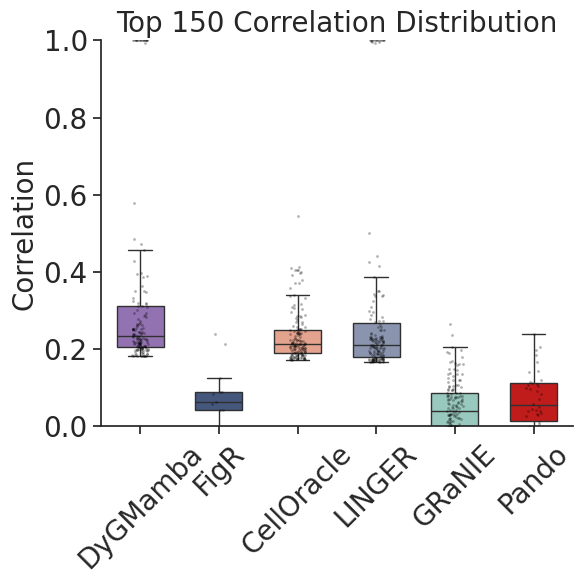

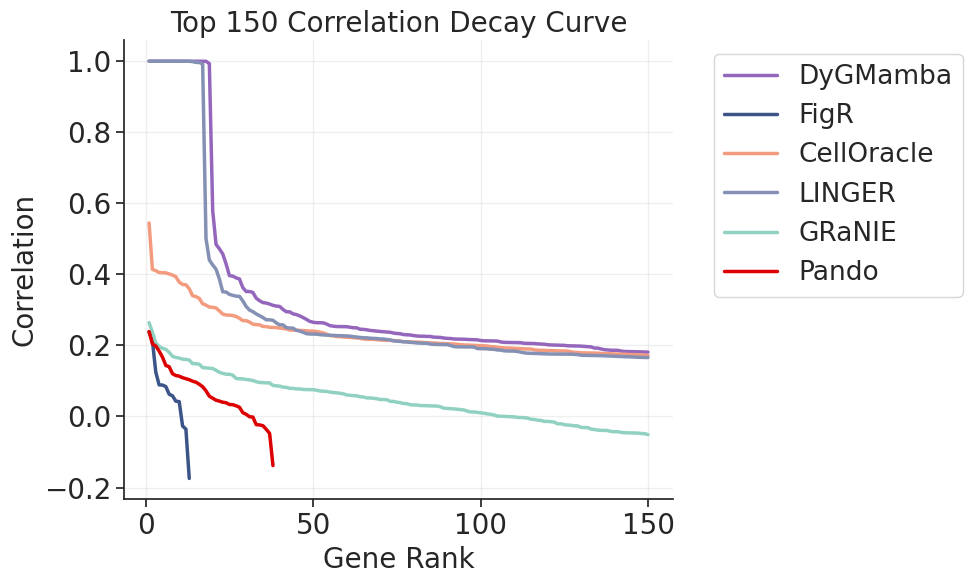

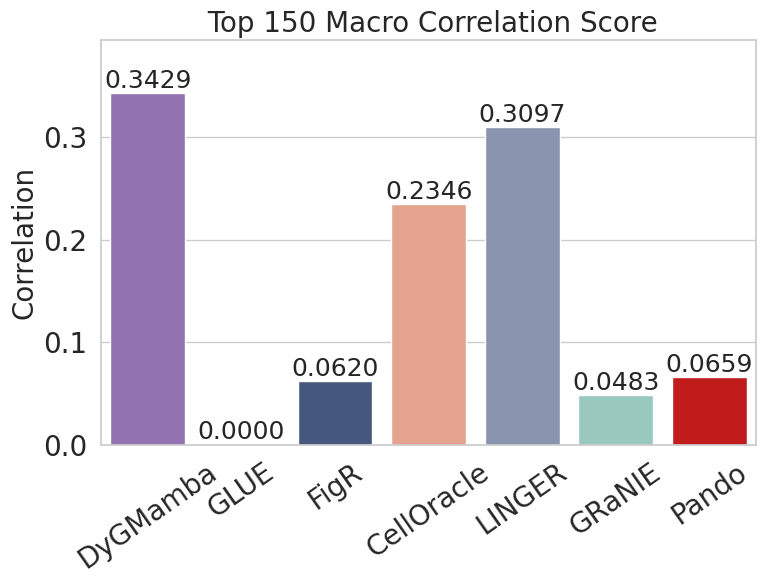

In [17]:
##############################################################################
#
# TF-Gene
#
##############################################################################
from benchmark.benchmark_model_new import dyg_tf_gene_result_inherit

if flag_tf_gene == True:
    
    avg_active_tf_gene_grn = dyg_tf_gene_result_inherit(data_path, model_result_path)

    tf_gene_correlation_result_dict, tf_gene_grn_dict, \
        precision_result_df, tf_gene_per_precision_dict = analysis_tf_gene_data(data_path, method_list, 
                                                            flag_corr = True, flag_precision = True, 
                                                            beta = beta)
        
    temp_list = []

    for k, df in tf_gene_correlation_result_dict.items():
        df_copy = df.copy() # 建议 copy 一下，避免修改原始字典里的数据
        df_copy['Method'] = k
        temp_list.append(df_copy)

    # 一次性按行合并
    tf_gene_per_corr_df = pd.concat(temp_list, axis=0, ignore_index=True)
    
    temp_list = []

    for k, df in tf_gene_per_precision_dict.items():
        df_copy = df.copy() # 建议 copy 一下，避免修改原始字典里的数据
        df_copy['Method'] = k
        temp_list.append(df_copy)

    # 一次性按行合并
    tf_gene_per_precision_df = pd.concat(temp_list, axis=0, ignore_index=True)
    
    with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:

        write_object_to_excel(tf_gene_per_corr_df, writer, "TF_gene_per_corr", used_sheets)
        
        write_object_to_excel(tf_gene_per_precision_df, writer, "TF_gene_per_precision", used_sheets)

        write_object_to_excel(precision_result_df, writer, "TF_gene_total_precision", used_sheets)

    print(precision_result_df)
    
        
    # 定义顺序 (防止自动排序乱掉)
    my_order = ['DyGMamba','GLUE', 'FigR', 'CellOracle', 
                'LINGER', 'GRaNIE', "Pando"]
    ###########################
    # Top 100 correlation

    plot_top_n_comparison(tf_gene_correlation_result_dict, 
                                output_path + "Benchmark of TF-Gene", palette = method_colors, 
                                top_n=150, 
                                score_col='Correlation', my_order=my_order, beta = beta)

    plot_top_n_mean_comparsion(tf_gene_correlation_result_dict, 
                                output_path + "Benchmark of TF-Gene", palette = method_colors,
                                top_n=150, 
                                score_col='Correlation', my_order=my_order, beta = beta)


    # #############################
    # # Total precision

    # plot_top_n_mean_comparsion(tf_gene_per_precision_dict, output_path + "Benchmark of TF-Gene Overall ", 
    #                             top_n=50, 
    #                             score_col='Precision', palette = method_colors, 
    #                             my_order=method_list, beta = beta)

    # plot_top_n_mean_comparsion(tf_gene_per_precision_dict, output_path + "Benchmark of TF-Gene Overall ", 
    #                             top_n=50,  score_col='Recall', palette = method_colors, 
    #                             my_order=method_list, beta = beta)

    # plot_top_n_mean_comparsion(tf_gene_per_precision_dict, output_path + "Benchmark of TF-Gene Overall ", 
    #                             top_n=50,  score_col='F_score', palette = method_colors, 
    #                             my_order=method_list, beta = beta)




    # plot_comparsion(precision_result_df, output_path + 'Benchmark of TF-Gene', 
    #                     score_col = "F-beta", palette=method_colors, my_order = method_list, beta = beta)

    # plot_comparsion(precision_result_df, output_path + 'Benchmark of TF-Gene', 
    #                     score_col = "Precision", palette=method_colors, my_order = method_list, beta = beta)


    # plot_top_n_comparison(tf_gene_per_precision_dict, 
    #                             output_path + "Benchmark of TF-Gene", palette = method_colors, 
    #                             top_n=50, 
    #                             score_col='F-beta', my_order=my_order, beta = beta)

    # plot_top_n_comparison(tf_gene_per_precision_dict, 
    #                             output_path + "Benchmark of TF-Gene", palette = method_colors, 
    #                             top_n=50, 
    #                             score_col='Recall', my_order=my_order, beta = beta)

    # plot_top_n_comparison(tf_gene_per_precision_dict, 
    #                             output_path + "Benchmark of TF-Gene", palette = method_colors, 
    #                             top_n=50, 
    #                             score_col='Precision', my_order=my_order, beta = beta)





# Test

In [18]:
benchmark_tf_peak_grn = pd.read_pickle(data_path + "process/benchmark_tf_region_network.pkl")

dyg_tf_peak_grn = pd.read_pickle(data_path + "process/dyg_tf_region_model.pkl")

In [19]:
benchmark_peak_gene_grn = pd.read_pickle(data_path + "process/benchmark_region_gene_network.pkl")

dyg_peak_gene_grn = pd.read_pickle(data_path + "process/dyg_region_gene_model.pkl")

In [20]:
benchmark_tf_gene_df = pd.merge(benchmark_tf_peak_grn, benchmark_peak_gene_grn,
                                on='Peak', suffixes=['_tf', '_gene'])

benchmark_tf_gene_grn = benchmark_tf_gene_df.groupby(['TF', 'Gene']).agg(
        peak_num=('Peak', 'nunique'),   # 对 Peak 列做去重计数，新列名叫 peak_num
        avg_weight=('value_gene', 'mean'),  # 对 weight 列做均值，新列名叫 avg_weight
        total_weight=('value_gene', 'sum')  # (可选) 建议顺便算个总权重
    ).reset_index()

benchmark_tf_gene_grn.drop_duplicates(subset=['TF', 'Gene'], inplace= True)

benchmark_tf_gene_grn

,TF,Gene,peak_num,avg_weight,total_weight
0,ATF3,BLTP2,1,46.450962,46.450962
1,ATF3,BTBD2,1,34.701664,34.701664
2,ATF3,CCDC106,1,64.795517,64.795517
3,ATF3,CD151,1,55.898804,55.898804
4,ATF3,CRKL,1,34.816715,34.816715
...,...,...,...,...,...
6004,YY1,ZNF335,1,80.136742,80.136742
6005,YY1,ZNF383,1,46.894611,46.894611
6006,YY1,ZNF581,1,40.994503,40.994503
6007,YY1,ZNF768,1,80.090256,80.090256


In [21]:
dyg_tf_gene_df = pd.merge(dyg_tf_peak_grn, dyg_peak_gene_grn,
                                on='Peak', suffixes=['_tf', '_gene'])

dyg_tf_gene_grn = dyg_tf_gene_df.groupby(['TF', 'Gene']).agg(
        peak_num=('Peak', 'nunique'),   # 对 Peak 列做去重计数，新列名叫 peak_num
        avg_weight=('value_gene', 'mean'),  # 对 weight 列做均值，新列名叫 avg_weight
        total_weight=('value_gene', 'sum')  # (可选) 建议顺便算个总权重
    ).reset_index()

dyg_tf_gene_grn.drop_duplicates(subset=['TF', 'Gene'], inplace= True)

dyg_tf_gene_grn


,TF,Gene,peak_num,avg_weight,total_weight
0,CREM,ACTN1,1,0.982001,0.982001
1,CREM,ACTN4,2,0.968635,1.937270
2,CREM,ADAT1,1,0.936627,0.936627
3,CREM,AHCY,1,0.940628,0.940628
4,CREM,ANKRD40,1,0.962420,0.962420
...,...,...,...,...,...
41211,ZNF768,ZNHIT1,11,0.949990,10.449891
41212,ZNF768,ZPR1,2,0.845787,1.691575
41213,ZNF768,ZSCAN32,9,0.963969,8.675717
41214,ZNF768,ZWILCH,6,0.928342,5.570053
